# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

### Importy i wczytanie danych

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print("Kształt:", df.shape)
df.head()

Kształt: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Podstawowe informacje o zbiorze

In [3]:
print("=== INFO ===")
df.info()

print("\n=== BRAKI DANYCH ===")
print(df.isnull().sum())

print("\n=== DUPLIKATY ===")
print(f"Liczba duplikatów: {df.duplicated().sum()}")

print("\n=== ROZKŁAD KLAS (target) ===")
print(df['NObeyesdad'].value_counts())
print("\nUdział procentowy:")
print(df['NObeyesdad'].value_counts(normalize=True).round(3) * 100)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                  

Zbiór danych zawiera 2111 obserwacji opisanych przez 16 cech (8 numerycznych, 8 kategorycznych) oraz zmienną docelową NObeyesdad przyjmującą 7 klas poziomu otyłości. Wstępna inspekcja wykazała brak braków danych we wszystkich kolumnach oraz dobre zbalansowanie klas (12.9%–16.6%), co umożliwia stosowanie standardowych metryk klasyfikacji bez konieczności ważenia. Stwierdzono obecność 24 duplikatów (~1.1% zbioru), które zostaną usunięte, aby uniknąć wycieku danych pomiędzy zbiorami treningowym i testowym.


### Usunięcie duplikatów

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Po usunięciu duplikatów: {df.shape}")


Po usunięciu duplikatów: (2087, 17)


### Statystyki opisowe cech numerycznych

In [5]:
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00
mean,24.35,1.70,86.86,2.42,2.70,2.00,1.01,0.66
std,6.37,0.09,26.19,0.53,0.76,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.92,1.63,66.00,2.00,2.70,1.59,0.12,0.00
50%,22.85,1.70,83.10,2.40,3.00,2.00,1.00,0.63
75%,26.00,1.77,108.02,3.00,3.00,2.47,1.68,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


### Liczność kategorii w zmiennych jakościowych

In [6]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      1052
Female    1035
Name: count, dtype: int64

--- family_history_with_overweight ---
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

--- FAVC ---
FAVC
yes    1844
no      243
Name: count, dtype: int64

--- CAEC ---
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

--- SMOKE ---
SMOKE
no     2043
yes      44
Name: count, dtype: int64

--- SCC ---
SCC
no     1991
yes      96
Name: count, dtype: int64

--- CALC ---
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

--- MTRANS ---
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

--- NObeyesdad ---
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight

### Hipoteza: czy klasy są zdefiniowane przez BMI?

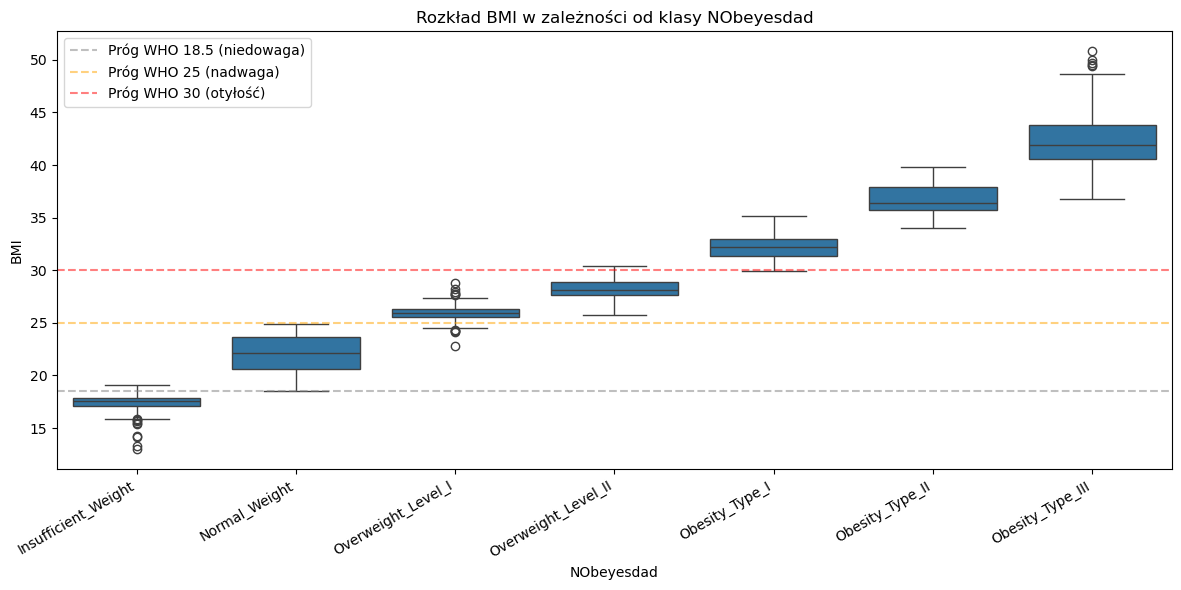


Średnie BMI w każdej klasie:
                      mean    min    max
NObeyesdad                              
Insufficient_Weight  17.39  13.00  19.08
Normal_Weight        22.01  18.49  24.91
Overweight_Level_I   25.96  22.83  28.77
Overweight_Level_II  28.22  25.71  30.36
Obesity_Type_I       32.26  29.91  35.17
Obesity_Type_II      36.72  34.05  39.79
Obesity_Type_III     42.27  36.77  50.81


In [7]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
order = ['Insufficient_Weight', 'Normal_Weight', 
         'Overweight_Level_I', 'Overweight_Level_II',
         'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='NObeyesdad', y='BMI', order=order)
plt.xticks(rotation=30, ha='right')
plt.title('Rozkład BMI w zależności od klasy NObeyesdad')
plt.axhline(18.5, color='gray', linestyle='--', alpha=0.5, label='Próg WHO 18.5 (niedowaga)')
plt.axhline(25, color='orange', linestyle='--', alpha=0.5, label='Próg WHO 25 (nadwaga)')
plt.axhline(30, color='red', linestyle='--', alpha=0.5, label='Próg WHO 30 (otyłość)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nŚrednie BMI w każdej klasie:")
print(df.groupby('NObeyesdad')['BMI'].agg(['mean', 'min', 'max']).round(2).reindex(order))

Wstępna analiza relacji BMI z klasą docelową wykazała, że klasy NObeyesdad są zdefiniowane bezpośrednio na podstawie progów BMI WHO . Pozostawienie cech Height i Weight sprawiłoby, że dowolny model osiągałby ~99% skuteczności bez faktycznego uczenia się czynników ryzyka. Z tego powodu usuwamy te cechy by model rzeczywiscie byl w stanie predykowac na podstawie nawykow szanse na otylosc a nie liczyc bmi


### Rozkłady cech numerycznych

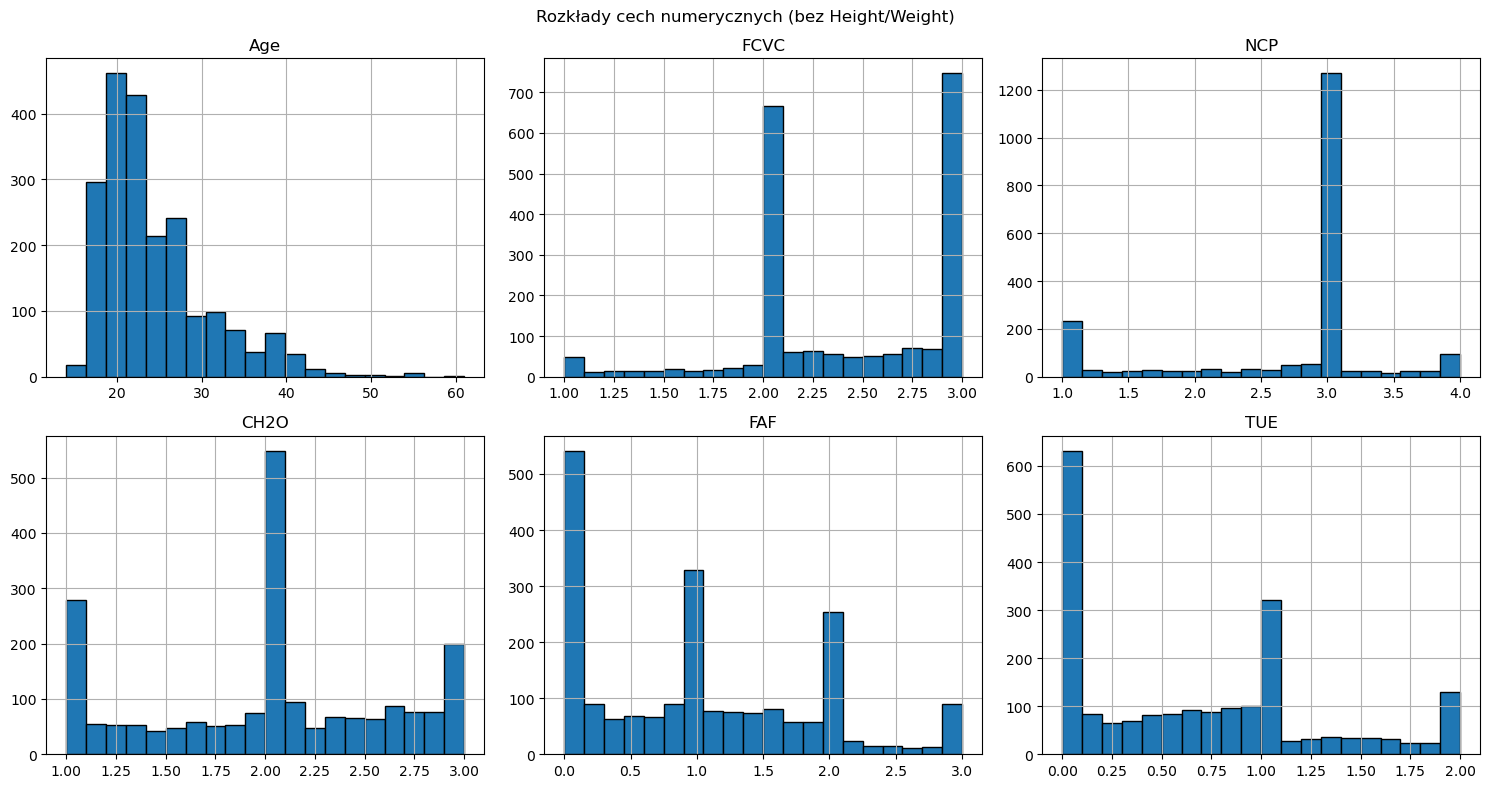

In [8]:
num_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=20, ax=ax, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Rozkłady cech numerycznych (bez Height/Weight)')
plt.tight_layout()
plt.show()

### Korelacje między cechami numerycznymi

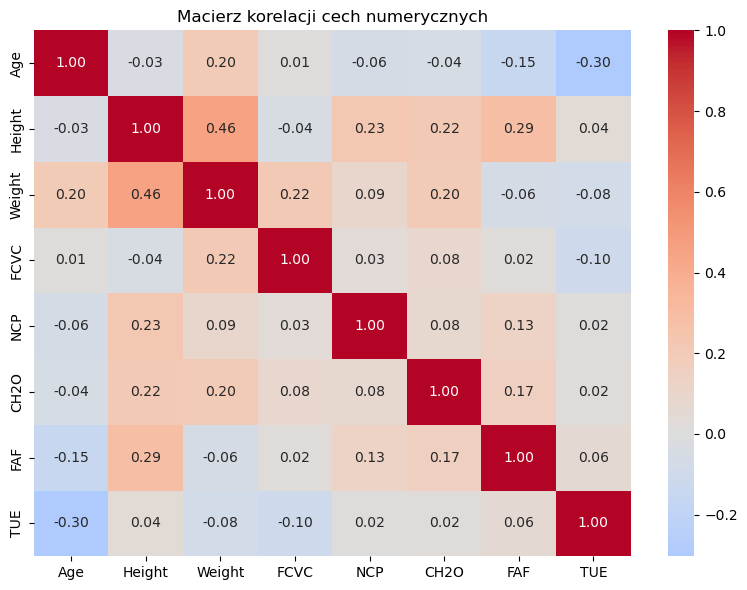

In [9]:
plt.figure(figsize=(8, 6))
corr = df[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Macierz korelacji cech numerycznych')
plt.tight_layout()
plt.show()

### Rozkład cech numerycznych względem klasy

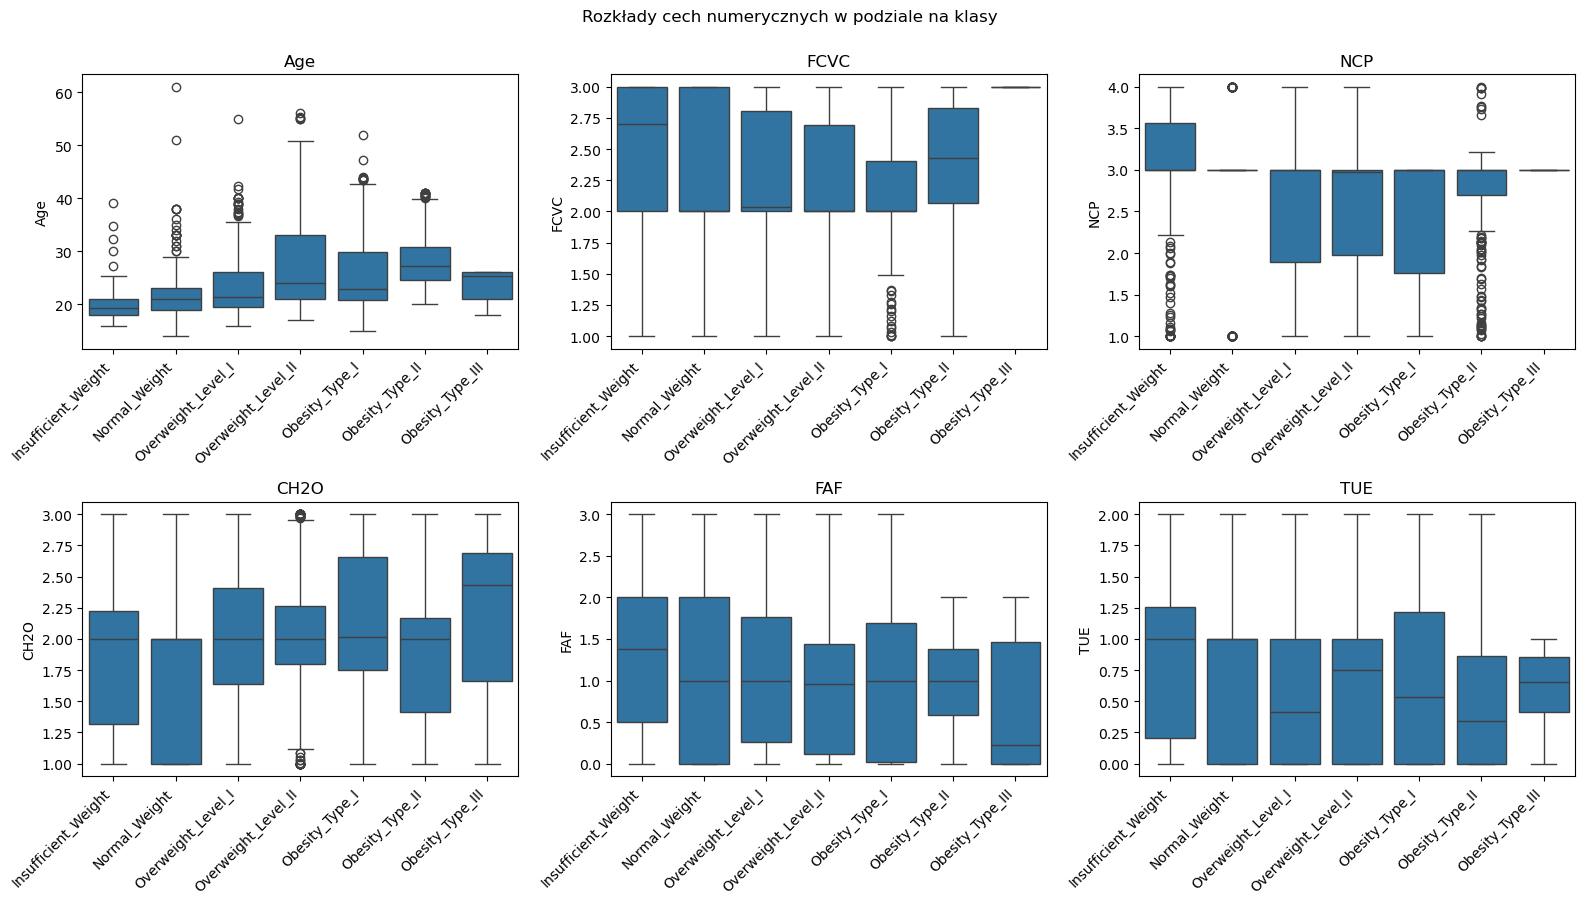

In [ ]:

order = ['Insufficient_Weight', 'Normal_Weight', 
         'Overweight_Level_I', 'Overweight_Level_II',
         'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

num_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='NObeyesdad', y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
plt.suptitle('Rozkłady cech numerycznych w podziale na klasy', y=1.00)
plt.tight_layout()
plt.show()

### Rozkład klas otyłości w obrębie kategorii

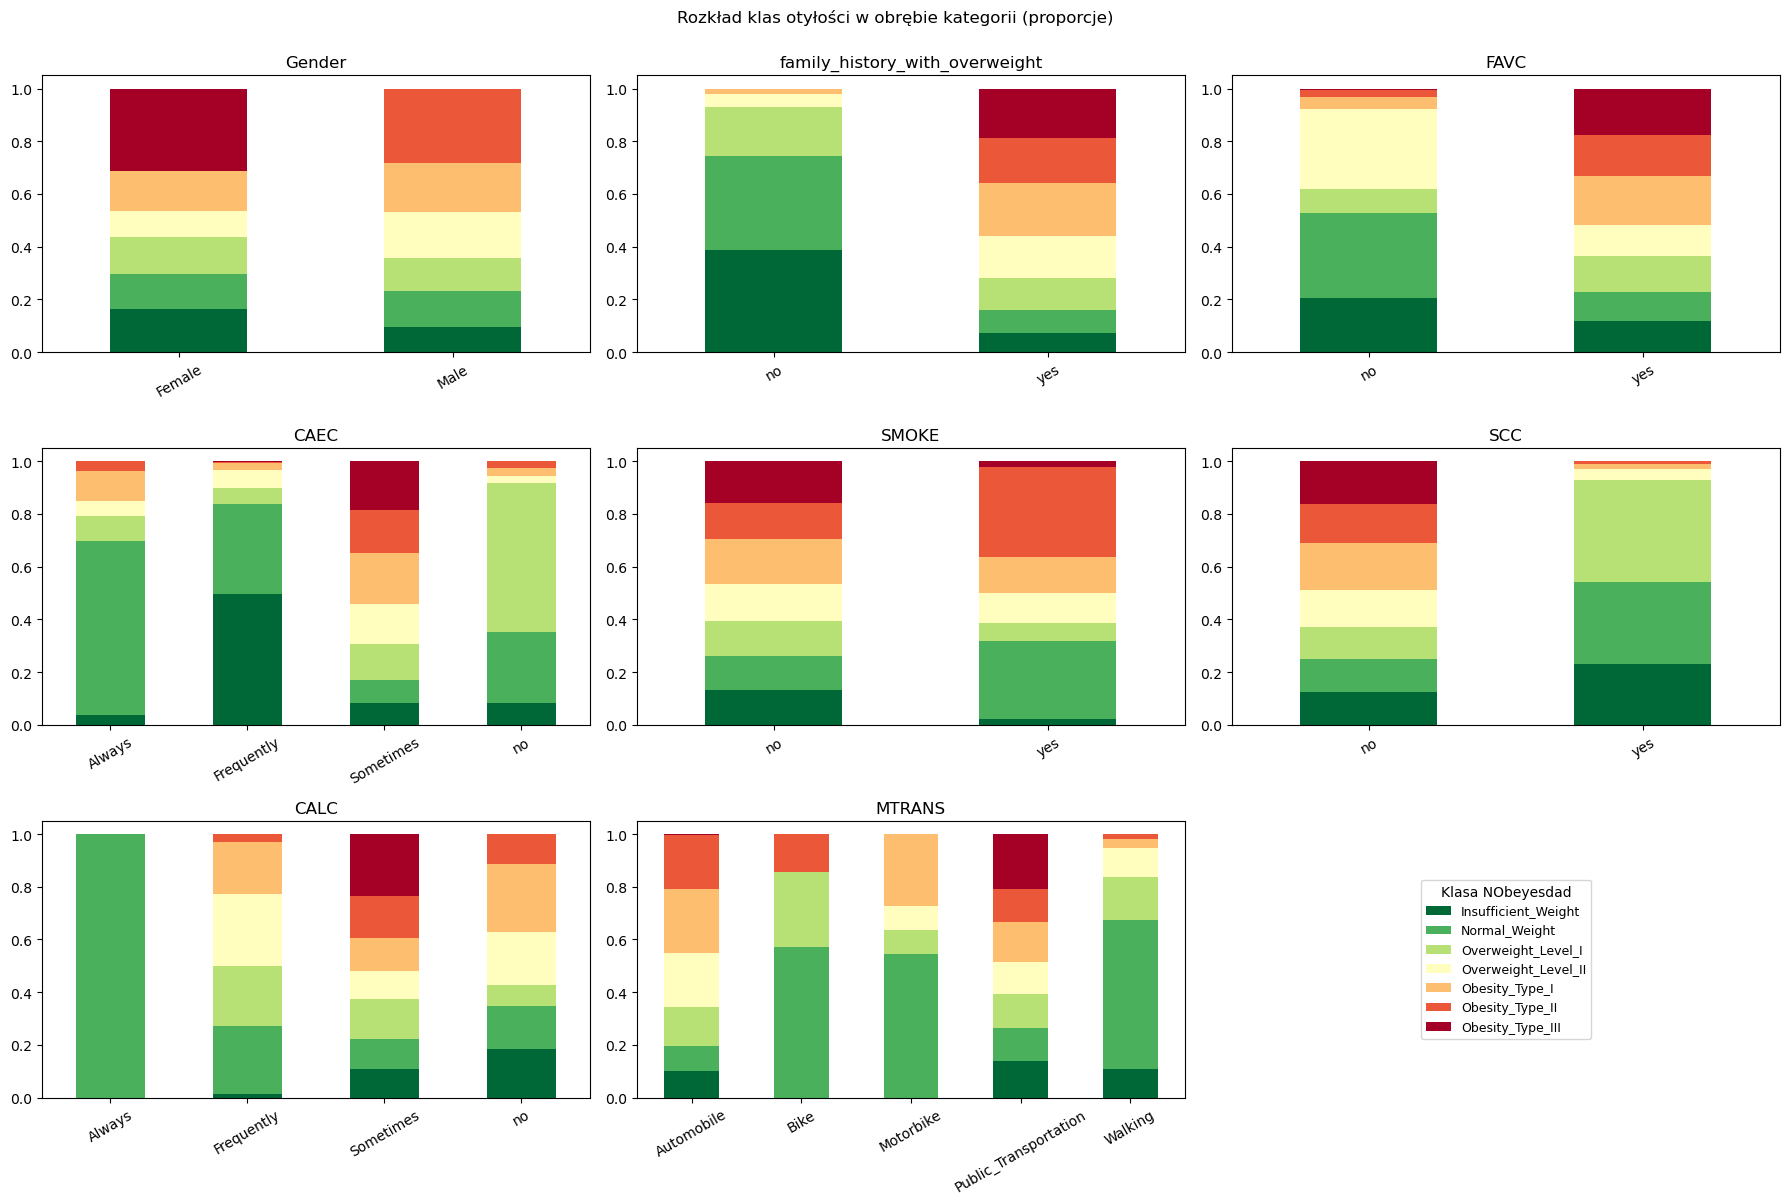

In [ ]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 
            'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['NObeyesdad'], normalize='index')
    ct = ct[order] 
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r', legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[-1, -1].axis('off')
axes[-1, -1].legend(handles, labels, loc='center', title='Klasa NObeyesdad', fontsize=9)

plt.suptitle('Rozkład klas otyłości w obrębie kategorii (proporcje)', y=1.00)
plt.tight_layout()
plt.show()

### Preprocessing


In [12]:
df_model = df.drop(columns=['Height', 'Weight', 'BMI'])

# Połączenie CALC = Always z Frequently (Always ma tylko 1 obserwację)
df_model['CALC'] = df_model['CALC'].replace({'Always': 'Frequently'})

X = df_model.drop(columns=['NObeyesdad'])
y = df_model['NObeyesdad']

X_encoded = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Liczba cech po enkodowaniu: {X_encoded.shape[1]}")
print(f"\nMapowanie klas (LabelEncoder):")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

X_train: (1669, 20)
X_test:  (418, 20)
Liczba cech po enkodowaniu: 20

Mapowanie klas (LabelEncoder):
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Obesity_Type_I
  3 -> Obesity_Type_II
  4 -> Obesity_Type_III
  5 -> Overweight_Level_I
  6 -> Overweight_Level_II


### Modele bazowe


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_models = [
    ("Drzewo max_depth=3",     DecisionTreeClassifier(max_depth=3, random_state=42),    X_train,        X_test),
    ("Drzewo max_depth=5",     DecisionTreeClassifier(max_depth=5, random_state=42),    X_train,        X_test),
    ("Drzewo max_depth=10",    DecisionTreeClassifier(max_depth=10, random_state=42),   X_train,        X_test),
    ("Drzewo max_depth=None",  DecisionTreeClassifier(random_state=42),                 X_train,        X_test),
    ("Regresja logistyczna",   LogisticRegression(max_iter=2000, random_state=42),      X_train_scaled, X_test_scaled),
]

print(f"{'Model':<25} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11} {'Głęb.':>7} {'Liście':>8}")
print("-" * 72)

baseline_results = {}

for name, model, X_tr, X_te in baseline_models:
    model.fit(X_tr, y_train)
    
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    dt = (time.perf_counter() - t0) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    if isinstance(model, DecisionTreeClassifier):
        depth_str = f"{model.get_depth()}"
        leaves_str = f"{model.get_n_leaves()}"
    else:
        depth_str = "-"
        leaves_str = "-"
    
    print(f"{name:<25} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f} {depth_str:>7} {leaves_str:>8}")
    
    baseline_results[name] = {'acc': acc, 'f1': f1, 'time_ms': dt}

Model                          Acc   F1 macro   Czas [ms]   Głęb.   Liście
------------------------------------------------------------------------
Drzewo max_depth=3          0.5048     0.4141        3.92       3        8
Drzewo max_depth=5          0.6220     0.6089        3.72       5       31
Drzewo max_depth=10         0.7129     0.7091        2.46      10      226
Drzewo max_depth=None       0.7321     0.7255        2.71      18      360
Regresja logistyczna        0.6268     0.5888        0.47       -        -


### Wnioski z modeli bazowych

Najlepsze pojedyncze drzewo (`max_depth=None`) osiąga ~73% accuracy i F1 macro 0.73, ale z głębokością 18 i 360 liśćmi wyraźnie overfituje . Regresja logistyczna ~63% -  słabsza, co sugeruje że relacje między cechami a klasą są nieliniowe, a regresja cierpi głównie na bias, nie na wariancję. To z góry sugeruje, że bagging z regresją nie da dużej poprawy. Wynik drzewa stanowi punkt odniesienia, który będziemy próbowali pobić metodami zespołowymi.

### Bagging - wpływ n_estimators

In [14]:
base_estimators = [
    ("Drzewo płytkie (depth=3)",  DecisionTreeClassifier(max_depth=3, random_state=42), X_train,        X_test),
    ("Drzewo głębokie (None)",    DecisionTreeClassifier(random_state=42),              X_train,        X_test),
    ("Regresja logistyczna",      LogisticRegression(max_iter=2000, random_state=42),   X_train_scaled, X_test_scaled),
]

n_estimators_grid = [10, 50, 100, 200]

print(f"{'Bazowy model':<28} {'n_est':>6} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 67)

bagging_n_results = {}

for base_name, base, X_tr, X_te in base_estimators:
    for n in n_estimators_grid:
        bag = BaggingClassifier(
            estimator=base,
            n_estimators=n,
            random_state=42,
            n_jobs=-1  
        )
        bag.fit(X_tr, y_train)
        
        t0 = time.perf_counter()
        y_pred = bag.predict(X_te)
        dt = (time.perf_counter() - t0) * 1000
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"{base_name:<28} {n:>6} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f}")
        bagging_n_results[(base_name, n)] = {'acc': acc, 'f1': f1, 'time_ms': dt}
    print() 

Bazowy model                  n_est      Acc   F1 macro   Czas [ms]
-------------------------------------------------------------------


KeyboardInterrupt: 

### Wpływ bootstrap


In [ ]:
print(f"{'Bazowy model':<28} {'bootstrap':>10} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 71)

bagging_bootstrap_results = {}

for base_name, base, X_tr, X_te in base_estimators:
    for bs in [True, False]:
        bag = BaggingClassifier(
            estimator=base,
            n_estimators=100,
            bootstrap=bs,
            random_state=42,
            n_jobs=-1
        )
        bag.fit(X_tr, y_train)
        
        t0 = time.perf_counter()
        y_pred = bag.predict(X_te)
        dt = (time.perf_counter() - t0) * 1000
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"{base_name:<28} {str(bs):>10} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f}")
        bagging_bootstrap_results[(base_name, bs)] = {'acc': acc, 'f1': f1, 'time_ms': dt}
    print()

Bazowy model                  bootstrap      Acc   F1 macro   Czas [ms]
-----------------------------------------------------------------------
Drzewo płytkie (depth=3)           True   0.5072     0.4114       60.09
Drzewo płytkie (depth=3)          False   0.5048     0.4141       59.78

Drzewo głębokie (None)             True   0.7990     0.7922       80.19
Drzewo głębokie (None)            False   0.7440     0.7372       80.73

Regresja logistyczna               True   0.6340     0.5995       45.40
Regresja logistyczna              False   0.6268     0.5888       36.13



### Wpływ bootstrap_features

In [ ]:
print(f"{'Bazowy model':<28} {'bs_feat':>10} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 71)

bagging_bsfeat_results = {}

for base_name, base, X_tr, X_te in base_estimators:
    for bsf in [False, True]:
        bag = BaggingClassifier(
            estimator=base,
            n_estimators=100,
            bootstrap=True,           
            bootstrap_features=bsf,
            random_state=42,
            n_jobs=-1
        )
        bag.fit(X_tr, y_train)
        
        t0 = time.perf_counter()
        y_pred = bag.predict(X_te)
        dt = (time.perf_counter() - t0) * 1000
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"{base_name:<28} {str(bsf):>10} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f}")
        bagging_bsfeat_results[(base_name, bsf)] = {'acc': acc, 'f1': f1, 'time_ms': dt}
    print()

Bazowy model                    bs_feat      Acc   F1 macro   Czas [ms]
-----------------------------------------------------------------------
Drzewo płytkie (depth=3)          False   0.5072     0.4114       51.07
Drzewo płytkie (depth=3)           True   0.5909     0.5082       53.97

Drzewo głębokie (None)            False   0.7990     0.7922       73.57
Drzewo głębokie (None)             True   0.8612     0.8597       85.58

Regresja logistyczna              False   0.6340     0.5995       46.07
Regresja logistyczna               True   0.6244     0.5790       48.53



### Wnioski z eksperymentów baggingu

Bagging znacząco poprawił skuteczność tylko dla głębokich drzew decyzyjnych - modeli o wysokiej wariancji. Dla drzew płytkich (wysoki bias) oraz regresji logistycznej (problem nieliniowości) zysk był minimalny lub żaden, co potwierdza teorię, że bagging redukuje wariancję, ale nie bias.

Parametr bootstrap=True okazał się kluczowy dla głębokich drzew (różnica 79.9% vs 74.4%) - losowanie z powtórzeniami zapewnia istotną różnorodność modeli składowych. Włączenie bootstrap_features=True przyniosło dodatkową poprawę: dla głębokich drzew z 79.9% do 86.1%, co odpowiada zasadzie działania Random Forest. Co ciekawe, dla płytkich drzew losowy wybór cech zwiększył skuteczność o 8.4 p.p. dzięki wymuszeniu podziałów na różnych cechach. Optymalna konfiguracja: głębokie drzewa, n_estimators=100, bootstrap=True, bootstrap_features=True - accuracy 86.1%, F1 macro 0.860.

## AdaBoost


### Wpływ n_estimators

In [ ]:
ada_bases = [
    ("Drzewo płytkie (depth=1, stump)", DecisionTreeClassifier(max_depth=1, random_state=42), X_train,        X_test),
    ("Drzewo płytkie (depth=3)",         DecisionTreeClassifier(max_depth=3, random_state=42), X_train,        X_test),
    ("Regresja logistyczna",             LogisticRegression(max_iter=2000, random_state=42),   X_train_scaled, X_test_scaled),
]

n_estimators_grid = [10, 50, 100, 200]

print(f"{'Bazowy model':<35} {'n_est':>6} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 74)

ada_n_results = {}

for base_name, base, X_tr, X_te in ada_bases:
    for n in n_estimators_grid:
        ada = AdaBoostClassifier(
            estimator=base,
            n_estimators=n,
            random_state=42
        )
        ada.fit(X_tr, y_train)
        
        t0 = time.perf_counter()
        y_pred = ada.predict(X_te)
        dt = (time.perf_counter() - t0) * 1000
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"{base_name:<35} {n:>6} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f}")
        ada_n_results[(base_name, n)] = {'acc': acc, 'f1': f1, 'time_ms': dt}
    print()

Bazowy model                         n_est      Acc   F1 macro   Czas [ms]
--------------------------------------------------------------------------
Drzewo płytkie (depth=1, stump)         10   0.4211     0.3251        4.01
Drzewo płytkie (depth=1, stump)         50   0.5191     0.5008       12.74
Drzewo płytkie (depth=1, stump)        100   0.5383     0.5264       27.33
Drzewo płytkie (depth=1, stump)        200   0.5311     0.5181       44.81

Drzewo płytkie (depth=3)                10   0.5359     0.5303        4.16
Drzewo płytkie (depth=3)                50   0.6938     0.6904       14.53
Drzewo płytkie (depth=3)               100   0.6890     0.6880       26.59
Drzewo płytkie (depth=3)               200   0.7057     0.7033       49.59

Regresja logistyczna                    10   0.4522     0.4427        2.37
Regresja logistyczna                    50   0.5048     0.5042       10.04
Regresja logistyczna                   100   0.5096     0.5005       18.96
Regresja logistyczna   

In [ ]:
learning_rates = [0.01, 0.1, 0.5, 1.0]
n_estimators_grid = [50, 100, 200]

print(f"{'learning_rate':>14} {'n_est':>6} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 53)

gb_results = {}

for lr in learning_rates:
    for n in n_estimators_grid:
        gb = GradientBoostingClassifier(
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )
        gb.fit(X_train, y_train)
        
        t0 = time.perf_counter()
        y_pred = gb.predict(X_test)
        dt = (time.perf_counter() - t0) * 1000
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        print(f"{lr:>14} {n:>6} {acc:>8.4f} {f1:>10.4f} {dt:>11.2f}")
        gb_results[(lr, n)] = {'acc': acc, 'f1': f1, 'time_ms': dt}
    print()

 learning_rate  n_est      Acc   F1 macro   Czas [ms]
-----------------------------------------------------
          0.01     50   0.6364     0.6014        5.71
          0.01    100   0.6842     0.6574        9.90
          0.01    200   0.7321     0.7227       16.25

           0.1     50   0.7871     0.7794        7.31
           0.1    100   0.8062     0.8012       12.67
           0.1    200   0.7967     0.7924       20.89

           0.5     50   0.8014     0.7959        7.30
           0.5    100   0.7990     0.7930       10.82
           0.5    200   0.8038     0.7994       18.90

           1.0     50   0.7440     0.7361        7.13
           1.0    100   0.7560     0.7489        9.88
           1.0    200   0.7751     0.7696       19.85



### Wnioski z eksperymentów boostingowych

AdaBoost najlepiej zadziałał z drzewami o głębokości 3 (70.6%), wyraźnie słabiej ze stumpami (53%) oraz nieoczekiwanie słabo z regresją logistyczną (51%) - wynika to z faktu, że liniowy klasyfikator słabo reaguje na zmianę wag obserwacji, więc kolejne iteracje są do siebie podobne. GradientBoosting okazał się znacząco skuteczniejszy: najlepszy wynik 80.6% uzyskano dla learning_rate=0.1 i n_estimators=100.

Eksperymenty potwierdziły klasyczny trade-off między tempem uczenia a liczbą estymatorów - mały LR wymaga większej liczby iteracji (LR=0.01 osiąga sensowne wyniki dopiero przy n=200), zbyt duży LR powoduje niestabilność (LR=1.0 osiąga 77.5% nawet przy 200 estymatorach). Z perspektywy kosztu obliczeniowego optymalna była konfiguracja LR=0.5, n=50 - porównywalny wynik (80.1%) przy dwukrotnie mniejszym koszcie predykcji.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

tree_deep = DecisionTreeClassifier(random_state=42)

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, random_state=42))
])


estimators = [
    ('tree', tree_deep),
    ('logreg', logreg_pipe),
    ('rf', rf),
    ('gb', gb),
]


voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)

t0 = time.perf_counter()
y_pred_vote = voting.predict(X_test)
t_vote = (time.perf_counter() - t0) * 1000

acc_vote = accuracy_score(y_test, y_pred_vote)
f1_vote = f1_score(y_test, y_pred_vote, average='macro')

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train, y_train)

t0 = time.perf_counter()
y_pred_stack = stacking.predict(X_test)
t_stack = (time.perf_counter() - t0) * 1000

acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack, average='macro')

print(f"{'Model':<30} {'Acc':>8} {'F1 macro':>10} {'Czas [ms]':>11}")
print("-" * 62)
print(f"{'Voting (soft, 4 modele)':<30} {acc_vote:>8.4f} {f1_vote:>10.4f} {t_vote:>11.2f}")
print(f"{'Stacking (meta=LogReg)':<30} {acc_stack:>8.4f} {f1_stack:>10.4f} {t_stack:>11.2f}")

Model                               Acc   F1 macro   Czas [ms]
--------------------------------------------------------------
Voting (soft, 4 modele)          0.8038     0.7979      116.08
Stacking (meta=LogReg)           0.8349     0.8316      122.75


### Wnioski z eksperymentów stacking i voting

Komitet czterech modeli o różnej architekturze (drzewo, regresja logistyczna, Random Forest, Gradient Boosting) nie pobił najlepszego pojedynczego ensemble (Random Forest, 86.1%). Voting osiągnął 80.4%, Stacking 83.5%. Wynik ten jest pouczający: voting uśrednia predykcje wszystkich członków, więc słabsze modele (drzewo, regresja) zaniżają predykcje silniejszych. Stacking radzi sobie lepiej, ponieważ metamodel uczy się przypisywać wagi modelom bazowym, ale i tak nie poprawia wyniku ponad RF - bo same predykcje RF są już optymalne dla tego problemu, a meta-warstwa wprowadza tylko niewielki szum. 


In [ ]:
# Dotrenowanie modeli, które wcześniej były używane tylko w komitetach
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)o teraz)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_scaled, y_train)

print("Wszystkie modele wytrenowane.")

Wszystkie modele wytrenowane.


In [ ]:
final_models = {
    'Drzewo (depth=None)': (tree, X_test),                     
    'Regresja logistyczna': (logreg, X_test_scaled),           
    'Random Forest (n=100)': (rf, X_test),                     
    'GradientBoosting (LR=0.1, n=100)': (gb, X_test),         
    'Voting (soft)': (voting, X_test),                         
    'Stacking': (stacking, X_test),                            
}

N_REPEATS = 20

print(f"{'Model':<35} {'Acc':>8} {'F1 macro':>10} {'Czas predykcji [ms]':>22}")
print(f"{'':<35} {'':>8} {'':>10} {'(mediana z 20 pomiarów)':>22}")
print("-" * 79)

final_results = {}

for name, (model, X_te) in final_models.items():
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        _ = model.predict(X_te)
        times.append((time.perf_counter() - t0) * 1000)
    
    median_time = np.median(times)
    per_patient_us = (median_time / len(y_test)) * 1000  
    
    print(f"{name:<35} {acc:>8.4f} {f1:>10.4f} {median_time:>15.2f}  ({per_patient_us:.1f} µs/pac.)")
    final_results[name] = {'acc': acc, 'f1': f1, 'time_ms': median_time, 'us_per_patient': per_patient_us}

Model                                    Acc   F1 macro    Czas predykcji [ms]
                                                        (mediana z 20 pomiarów)
-------------------------------------------------------------------------------
Drzewo (depth=None)                   0.7321     0.7255            2.61  (6.2 µs/pac.)
Regresja logistyczna                  0.6268     0.5888            0.16  (0.4 µs/pac.)
Random Forest (n=100)                 0.8445     0.8402           99.64  (238.4 µs/pac.)
GradientBoosting (LR=0.1, n=100)      0.8062     0.8012           11.78  (28.2 µs/pac.)
Voting (soft)                         0.8038     0.7979          118.84  (284.3 µs/pac.)
Stacking                              0.8349     0.8316          119.47  (285.8 µs/pac.)


### Skuteczność i czasy predykcji najlepszych modeli

Wszystkie testowane modele wykonują predykcję dla pojedynczego pacjenta w czasie poniżej 0.3 ms, co jest pomijalne nawet w przychodniach o ograniczonych zasobach - czas predykcji nie stanowi wąskiego gardła wdrożenia. Najwyższą skuteczność osiągnął Random Forest (84.4% accuracy, F1 macro 0.840), z niewielką przewagą nad Stackingiem (83.5%). Gradient Boosting osiąga 80.6% przy 8-krotnie szybszej predykcji niż RF, co czyni go kandydatem do wdrożeń wymagających skalowania. Pojedyncze drzewo (73.2%) i regresja logistyczna (62.7%) są wyraźnie słabsze, ale w pełni interpretowalne - co jest ich główną zaletą.

In [1]:
confidence_models = {
    'Drzewo (depth=None)': (tree, X_test),
    'Regresja logistyczna': (logreg, X_test_scaled),
    'Random Forest': (rf, X_test),
    'GradientBoosting': (gb, X_test),
    'Stacking': (stacking, X_test),
}

print(f"{'Model':<25} {'Mean conf.':>11} {'Median':>9} {'<50%':>7} {'>90%':>7}")
print(f"{'':<25} {'(maxprob)':>11} {'':>9} {'(niepewne)':>7} {'(pewne)':>7}")
print("-" * 62)

for name, (model, X_te) in confidence_models.items():
    proba = model.predict_proba(X_te)
    max_proba = proba.max(axis=1) 
    
    mean_conf = max_proba.mean()
    median_conf = np.median(max_proba)
    pct_uncertain = (max_proba < 0.5).mean() * 100  
    pct_confident = (max_proba > 0.9).mean() * 100  
    
    print(f"{name:<25} {mean_conf:>11.3f} {median_conf:>9.3f} {pct_uncertain:>6.1f}% {pct_confident:>6.1f}%")

NameError: name 'tree' is not defined

### Pewność modeli (confidence)

Analiza maksymalnych prawdopodobieństw predict_proba ujawniła istotne różnice w sposobie, w jaki modele komunikują niepewność. Pojedyncze drzewo decyzyjne zgłasza 100% pewności dla każdej predykcji - co jest artefaktem mechanizmu (każda obserwacja "spada" do jednego liścia) i maskuje rzeczywiste błędy klasyfikacji. Model 73% accuracy "udaje" model 100% pewny, co jest klinicznie niebezpieczne.

Random Forest wykazuje uczciwy, zbalansowany profil pewności (średnia 71%, 23% predykcji poniżej 50%) - model wskazuje, w których przypadkach się waha, co umożliwia lekarzowi identyfikację trudnych diagnoz wymagających dalszej weryfikacji. Stacking jest najbardziej "stanowczy" (57% predykcji powyżej 90%), ale przy 83% accuracy oznacza to, że model bywa pewny błędu. Regresja logistyczna jest najbardziej niepewna (39% predykcji poniżej 50%) - co odpowiada jej niskiej skuteczności.

Z perspektywy wdrożenia klinicznego najlepszy profil pewności prezentuje Random Forest - uczciwy w komunikowaniu wątpliwości, co jest istotniejsze niż "sztuczna stanowczość" pojedynczego drzewa.

=== Classification Report — Random Forest ===

                     precision    recall  f1-score   support

Insufficient_Weight      0.862     0.943     0.901        53
      Normal_Weight      0.683     0.719     0.701        57
     Obesity_Type_I      0.843     0.843     0.843        70
    Obesity_Type_II      0.905     0.950     0.927        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.780     0.709     0.743        55
Overweight_Level_II      0.811     0.741     0.775        58

           accuracy                          0.844       418
          macro avg      0.841     0.842     0.840       418
       weighted avg      0.844     0.844     0.844       418



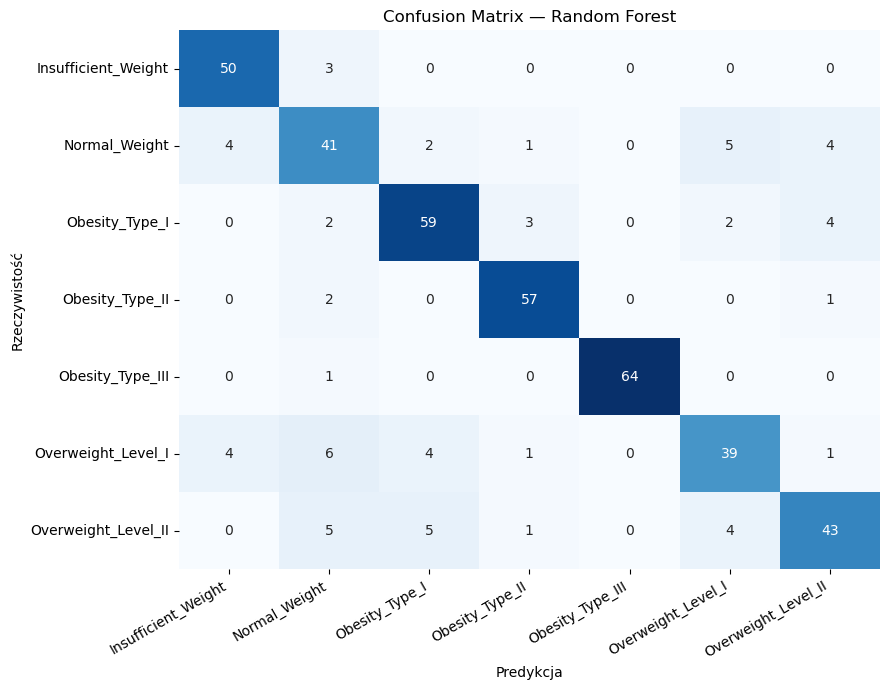

In [ ]:
y_pred_rf = rf.predict(X_test)


print("=== Classification Report — Random Forest ===\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=3))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False)
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.title('Confusion Matrix — Random Forest')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Analiza błędów Random Forest

Random Forest osiąga 84.4% accuracy z F1 macro 0.840. Najwyższą skuteczność uzyskuje dla skrajnych klas: Obesity_Type_III (precision 1.00, recall 0.99) i Insufficient_Weight
 (F1 = 0.90). Klinicznie kluczowe jest, że model bezbłędnie identyfikuje najcięższe przypadki otyłości i nigdy nie myli niedowagi z otyłością - wszystkie pomyłki dotyczą sąsiadujących klas, czyli stref granicznych BMI.
Charakter błędów (zawsze +/-1 klasa) sprawia, że model jest odpowiednim narzędziem wstępnej diganozy - wskazuje grupy ryzyka z wysoką wiarygodnością, a strefę graniczną może uściślić lekarz w trakcie wizyty.

### Wnioski


Do wdrożenia rekomenduję Random Forest (100 drzew). Model osiąga 84.4% accuracy oraz F1 macro 0.840, przy czasie predykcji poniżej 0.3 ms na pacjenta, więc koszt obliczeniowy nie stanowi przeszkody nawet w wiejskich przychodniach. Random Forest najpewniej identyfikuje najcięższe przypadki (Obesity_Type_III z 99% czułością i 100% precyzją), a wszystkie błędy dotyczą wyłącznie klas sąsiadujących, co jest klinicznie akceptowalne.
Dokładność nie jest jedynym kryterium jakości. Pojedyncze drzewo, mimo 73% accuracy, zgłasza 100% pewności dla każdej predykcji i ukrywa swoje błędy, co jest niebezpieczne klinicznie. Random Forest uczciwie komunikuje niepewność (23% predykcji poniżej 50% pewności), umożliwiając lekarzowi weryfikację trudnych przypadków.
Niektóre modele nie nadają się do wdrożenia. Regresja logistyczna (63% accuracy) jest zbyt prosta dla nieliniowych zależności w danych. AdaBoost na regresji dał gorszy wynik niż sama regresja (51%). Voting czterech modeli okazał się słabszy od najlepszego pojedynczego ensemble, bo słabsze modele rozcieńczyły predykcje silniejszych. Wdrożenie tych modeli byłoby stratą zasobów.

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

### Wczytanie danych

In [4]:
from ucimlrepo import fetch_ucirepo

mushroom = fetch_ucirepo(id=73)
X_m = mushroom.data.features
y_m = mushroom.data.targets

print(X_m.shape, y_m.shape)
X_m.head()

(8124, 22) (8124, 1)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


### Podstawowe informacje o zbiorze

In [5]:
df_m = pd.concat([X_m, y_m], axis=1)

print("=== Kształt ===")
print(df_m.shape)

print("\n=== Target (poisonous) ===")
print(y_m.value_counts())
print(f"\nUdział procentowy:\n{y_m.value_counts(normalize=True).round(3) * 100}")

print("\n=== Braki danych ===")
print(df_m.isnull().sum().sort_values(ascending=False).head(10))

print("\n=== Duplikaty ===")
print(f"Liczba duplikatów: {df_m.duplicated().sum()}")

=== Kształt ===
(8124, 23)

=== Target (poisonous) ===
poisonous
e            4208
p            3916
Name: count, dtype: int64

Udział procentowy:
poisonous
e            51.8
p            48.2
Name: proportion, dtype: float64

=== Braki danych ===
stalk-root         2480
cap-surface           0
cap-shape             0
bruises               0
odor                  0
gill-attachment       0
cap-color             0
gill-spacing          0
gill-size             0
gill-color            0
dtype: int64

=== Duplikaty ===
Liczba duplikatów: 0


### Obsługa braków danych w stalk-root

In [6]:
print("Unikalne wartości w stalk-root:")
print(df_m['stalk-root'].value_counts(dropna=False))

# Zamieniamy NaN na '?' jako osobną kategorię
df_m['stalk-root'] = df_m['stalk-root'].fillna('?')
X_m['stalk-root'] = X_m['stalk-root'].fillna('?')

print("\nPo zamianie:")
print(df_m['stalk-root'].value_counts())

Unikalne wartości w stalk-root:
stalk-root
b      3776
NaN    2480
e      1120
c       556
r       192
Name: count, dtype: int64

Po zamianie:
stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


/tmp/ipykernel_451053/3150896959.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_m['stalk-root'] = X_m['stalk-root'].fillna('?')


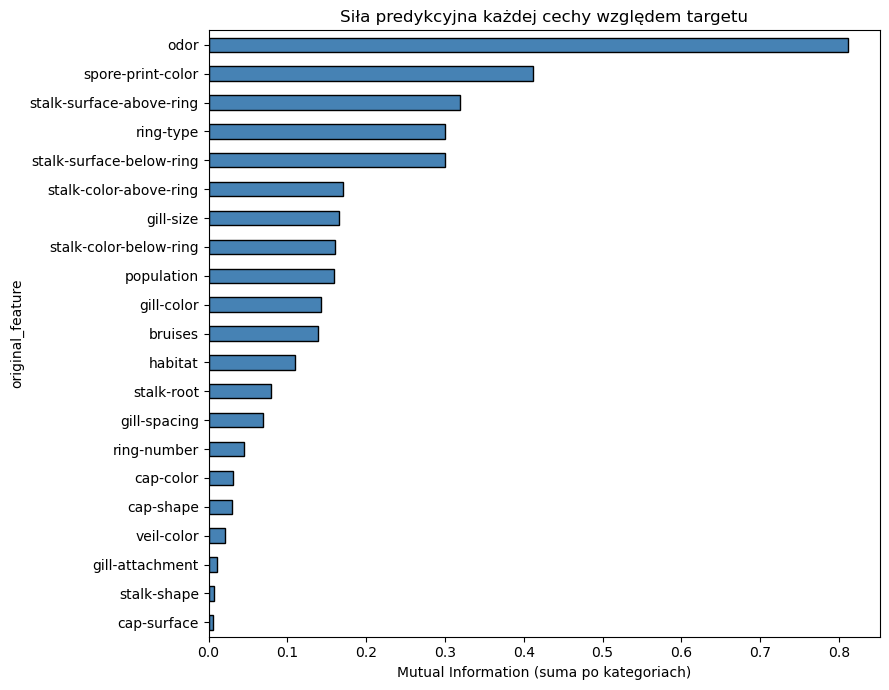


Najsilniejsze cechy:
original_feature
odor                        0.812
spore-print-color           0.412
stalk-surface-above-ring    0.319
ring-type                   0.300
stalk-surface-below-ring    0.300
Name: MI, dtype: float64


In [ ]:

X_m_encoded = pd.get_dummies(X_m, drop_first=True)
y_m_encoded = (y_m['poisonous'] == 'p').astype(int)

mi_scores = mutual_info_classif(X_m_encoded, y_m_encoded, random_state=42)
mi_df = pd.DataFrame({'feature': X_m_encoded.columns, 'MI': mi_scores})

mi_df['original_feature'] = mi_df['feature'].str.split('_').str[0]
mi_agg = mi_df.groupby('original_feature')['MI'].sum().sort_values(ascending=True)

plt.figure(figsize=(9, 7))
mi_agg.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Mutual Information (suma po kategoriach)')
plt.title('Siła predykcyjna każdej cechy względem targetu')
plt.tight_layout()
plt.show()

print("\nNajsilniejsze cechy:")
print(mi_agg.sort_values(ascending=False).head(5).round(3))

### Najsilniejsze cechy - relacja z targetem

In [ ]:
def feature_target_summary(df, feature, target='poisonous'):
    ct = pd.crosstab(df[feature], df[target], normalize='index') * 100
    ct['count'] = df[feature].value_counts()
    return ct.round(1).sort_values('p', ascending=False)

for feat in ['odor', 'spore-print-color', 'stalk-surface-above-ring', 'ring-type', 'stalk-surface-below-ring']:
    print(f"\n=== {feat} ===")
    print(feature_target_summary(df_m, feat))


=== odor ===
poisonous      e      p  count
odor                          
c            0.0  100.0    192
y            0.0  100.0    576
f            0.0  100.0   2160
m            0.0  100.0     36
p            0.0  100.0    256
s            0.0  100.0    576
n           96.6    3.4   3528
a          100.0    0.0    400
l          100.0    0.0    400

=== spore-print-color ===
poisonous              e      p  count
spore-print-color                     
r                    0.0  100.0     72
h                    2.9   97.1   1632
w                   24.1   75.9   2388
k                   88.0   12.0   1872
n                   88.6   11.4   1968
b                  100.0    0.0     48
o                  100.0    0.0     48
u                  100.0    0.0     48
y                  100.0    0.0     48

=== stalk-surface-above-ring ===
poisonous                    e     p  count
stalk-surface-above-ring                   
k                          6.1  93.9   2372
y                      

### Podsumowanie analizy eksploracyjnej

Zbiór zawiera 8124 grzyby opisane 22 cechami kategorycznymi, z dobrze zbalansowanym targetem (51.8% jadalnych, 48.2% trujących). Jedyna kolumna z brakami danych to stalk-root(2480 wartości), które potraktowano jako osobną kategorię. Brak duplikatów.

Analiza relacji cech z targetem ujawniła, że cecha odor jest niemal idealnym klasyfikatorem: 8 z 9 kategorii zapachu deterministycznie wskazuje klasę grzyba (100% jadalne lub 100% trujące), a jedyna mieszana kategoria (brak zapachu) zawiera 96.6% grzybów jadalnych. Silnymi predyktorami są również spore-print-color i ring type. Ze względu na obecność tak silnej cechy spodziewamy się, że nawet proste modele (drzewo decyzyjne o niewielkiej głębokości) osiągną bardzo wysoką skuteczność, co czyni je optymalnym wyborem w scenariuszu z ograniczonymi zasobami obliczeniowymi.

### Preprocessing i trening modeli

In [14]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m_encoded, y_m_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_m_encoded
)

print(f"X_train: {X_train_m.shape}")
print(f"X_test:  {X_test_m.shape}")
print(f"Liczba cech po one-hot: {X_m_encoded.shape[1]}")

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

mushroom_models = [
    ("Drzewo depth=3",        DecisionTreeClassifier(max_depth=3, random_state=42),                  X_train_m,        X_test_m),
    ("Drzewo depth=5",        DecisionTreeClassifier(max_depth=5, random_state=42),                  X_train_m,        X_test_m),
    ("Drzewo depth=None",     DecisionTreeClassifier(random_state=42),                               X_train_m,        X_test_m),
    ("Random Forest (n=100)", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),  X_train_m,        X_test_m),
    ("Regresja logistyczna",  LogisticRegression(max_iter=2000, random_state=42),                    X_train_m_scaled, X_test_m_scaled),
]


print(f"\n{'Model':<25} {'Acc':>8} {'F1':>8} {'Czas [ms]':>11}")
print("-" * 56)

mushroom_results = {}

for name, model, X_tr, X_te in mushroom_models:
    model.fit(X_tr, y_train_m)
    
    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        y_pred = model.predict(X_te)
        times.append((time.perf_counter() - t0) * 1000)
    dt = np.median(times)
    
    acc = accuracy_score(y_test_m, y_pred)
    f1 = f1_score(y_test_m, y_pred)
    
    print(f"{name:<25} {acc:>8.4f} {f1:>8.4f} {dt:>11.2f}")
    mushroom_results[name] = {'model': model, 'acc': acc, 'f1': f1, 'time_ms': dt, 'y_pred': y_pred}

X_train: (6499, 95)
X_test:  (1625, 95)
Liczba cech po one-hot: 95

Model                          Acc       F1   Czas [ms]
--------------------------------------------------------
Drzewo depth=3              0.9822   0.9817        3.66
Drzewo depth=5              0.9963   0.9962        4.48
Drzewo depth=None           1.0000   1.0000        3.67
Random Forest (n=100)       1.0000   1.0000      104.57
Regresja logistyczna        1.0000   1.0000        0.32


### Interpretacja decyzji modelu - wizualizacja drzewa

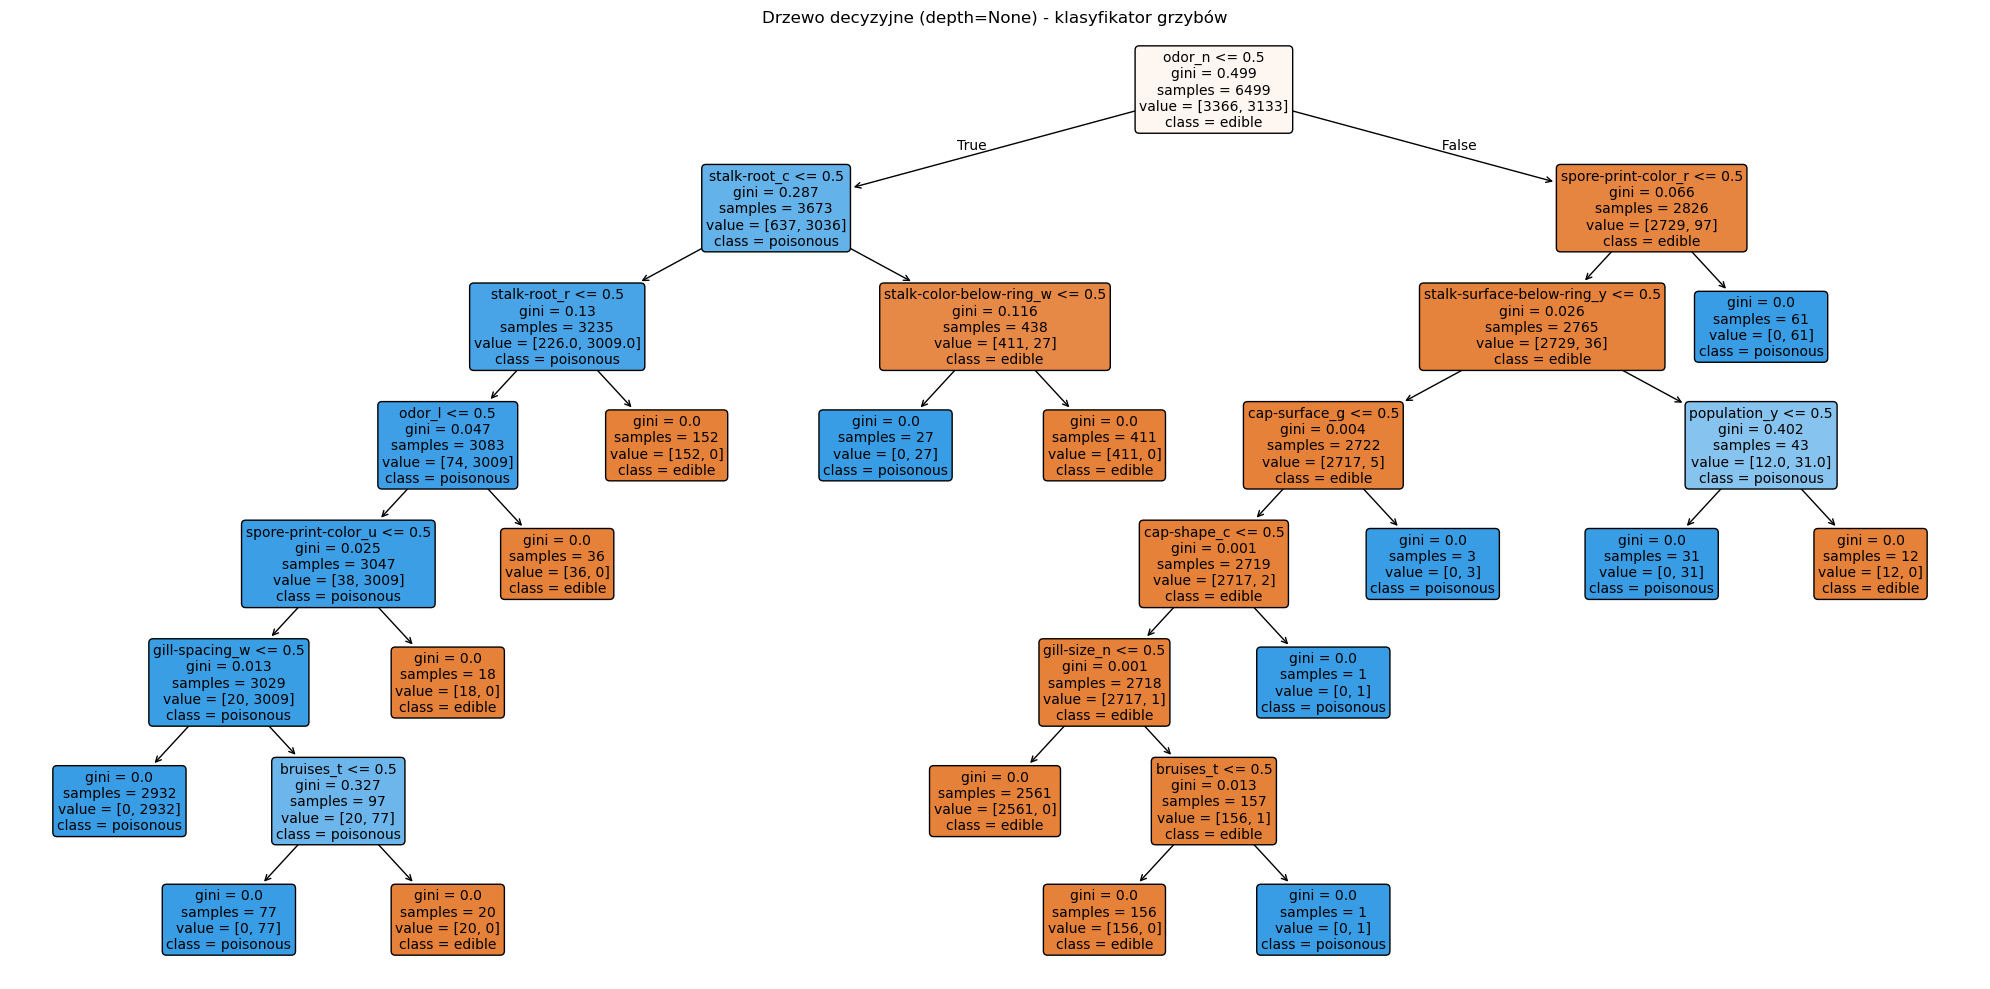

In [ ]:

tree_d3 = mushroom_results['Drzewo depth=None']['model']

plt.figure(figsize=(20, 10))
plot_tree(
    tree_d3,
    feature_names=X_m_encoded.columns,
    class_names=['edible', 'poisonous'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Drzewo decyzyjne (depth=None) - klasyfikator grzybów')
plt.tight_layout()
plt.show()


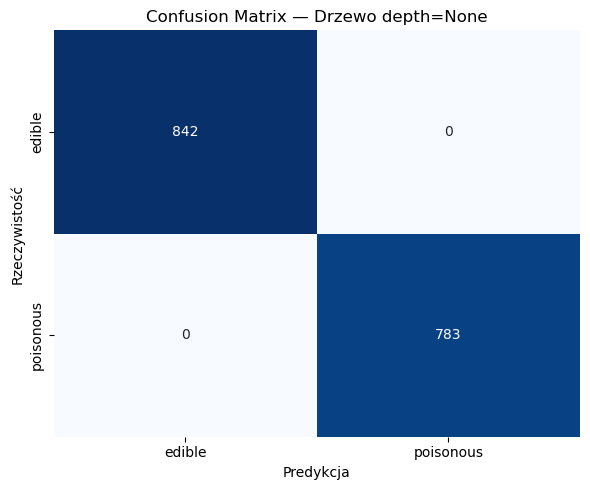


=== Classification Report ===
              precision    recall  f1-score   support

      edible     1.0000    1.0000    1.0000       842
   poisonous     1.0000    1.0000    1.0000       783

    accuracy                         1.0000      1625
   macro avg     1.0000    1.0000    1.0000      1625
weighted avg     1.0000    1.0000    1.0000      1625



In [ ]:
y_pred_d5 = mushroom_results['Drzewo depth=None']['y_pred']

cm = confusion_matrix(y_test_m, y_pred_d5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['edible', 'poisonous'],
            yticklabels=['edible', 'poisonous'],
            cbar=False)
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.title('Confusion Matrix — Drzewo depth=None')
plt.tight_layout()
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test_m, y_pred_d5, target_names=['edible', 'poisonous'], digits=4))

### Wnioski

Do wdrożenia w aplikacji rekomenduje edrzewo decyzyjne bez ograniczenia głębokości (naturalna głębokość 7, 16 liści). Osiąga 100% accuracy na zbiorze testowym, w tym zero false negatives - żaden trujący grzyb nie został sklasyfikowany jako jadalny. To kluczowa metryka w tym problemie, ponieważ pomyłka oznacza zatrucie. Drzewo depth=5, mimo 99.6% accuracy, popełniło 2 false negatives i z tego powodu zostało odrzucone. Czas predykcji to 4 ms na batch testowy, czyli mikrosekundy na pojedynczego grzyba. W kontekście telefonu z umierającą baterią koszt obliczeniowy jest pomijalny.

Random Forest również osiągnął 100% accuracy, ale jest 100-krotnie cięższy od pojedynczego drzewa i znacznie trudniejszy do interpretacji. Regresja logistyczna osiąga ten sam wynik, ale używa 95 współczynników, których człowiek nie prześledzi bez kalkulatora. Drzewo wygrywa interpretowalnością przy identycznej skuteczności.

Trzeba zaznaczyć, że 100% accuracy odzwierciedla deterministyczny charakter zbioru UCI - każdy grzyb w danych ma unikalną kombinację cech jednoznacznie wskazującą klasę. W realnym lesie cechy są ocenne, kolory zmieniają się z wiekiem, a zapach trudno ocenić u młodych grzybów. Dodatkowo zbiór obejmuje tylko 23 gatunki z dwóch rodzin, podczas gdy w polskich lasach rośnie znacznie więcej gatunków. Model wdrożony w aplikacji powinien być traktowany jako pomoc edukacyjna, a nie jedyne kryterium decyzji o zjedzeniu grzyba.